In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import warnings
import time
from pyextremes import plot_mean_residual_life, plot_parameter_stability, plot_threshold_stability, plot_return_value_stability

Code used to create event catalogue and dataset

In [ ]:
# var_names = {"TEMP": "temp", "TIME": "time", "DEPTH": "depth", "LATITUDE": "lat", "LONGITUDE": "lon"}
# ors = xr.open_dataset("data/temp_combined_ORS065_1990_2024.nc").rename(var_names)

# daily_ors = resample_daily(ors, "temp")

# threshold_specs = make_threshold_specs(
#     quantiles=np.arange(0.7, 0.999, 0.001),
#     offsets=np.arange(0.0, 4.01, 0.01),
#     std_multiples=np.arange(0.0, 4.01, 0.01),
# )

# print("Running MHW detection workflow...")
# start_time = time.perf_counter()
# ors_result = run_mhw_detection(
#     daily_ors,
#     threshold_specs=threshold_specs,
#     # baseline=daily_ors.sel(time=slice("1991", "2020")),
#     pool_window=11,
#     smooth_window=31,
#     min_samples=30,
#     max_gap=2,
#     min_duration=5,
#     validate_nesting=True,
#     multiindex=True,
# )
# print(f"Processing time: {time.perf_counter() - start_time:.2f} s")

# ors_result["data"].to_netcdf("data/mhw_events_data.nc")
# ors_result["events"].to_pickle("data/mhw_events_catalogue.pkl")

In [14]:
# mhw_events_ors = pd.read_pickle("data/mhw_events_ors.pkl")
mhw_events_ors = pd.read_pickle("data/mhw_events_ors.pkl")
mhw_events_imos = pd.read_pickle("data/mhw_events_imos.pkl")

mhw_events_catalogue = pd.read_pickle("data/mhw_events_catalogue.pkl")
mhw_all_data = xr.open_dataset("data/mhw_all_data.nc")

In [43]:
mhw_events_ors_quantile = mhw_events_ors.xs("quantile", level='threshold_method').reset_index()
mhw_events_ors_std = mhw_events_ors.xs("std", level='threshold_method').reset_index()
mhw_events_ors_offset = mhw_events_ors.xs("offset", level='threshold_method').reset_index()

## Plot of Cumulative Intensity vs Duration vs Mean Intensity for MHW Events at a Given Depth

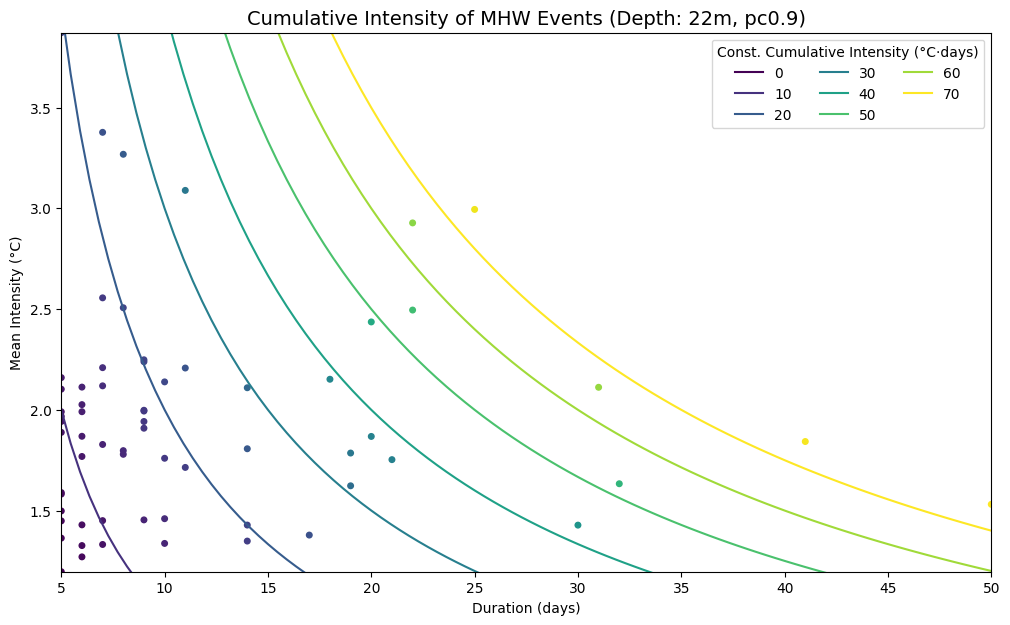

In [95]:
method = "quantile"
value = 0.9
depth = 22

mhw_events_plot = select_events_by_threshold(mhw_events_catalogue, "quantile", 0.9).xs(depth, level='depth')

fig, ax = plt.subplots(figsize=(12, 7))

# plot surfaces of constant cumulative intensity
const_cum_i = list(range(0,round(mhw_events_plot.cumulative_intensity.max())+1,10))
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(const_cum_i)))
duration_range = np.linspace(mhw_events_plot.duration.min(), mhw_events_plot.duration.max(), 100)
for i in range(len(const_cum_i)):
    cum_i = const_cum_i[i]
    plt.plot(duration_range, cum_i / duration_range, label=f"{cum_i}", color=colors[i])

# plot events by mean intensity vs duration, colored by cumulative intensity
sc = ax.scatter(
    mhw_events_plot["duration"],
    mhw_events_plot["mean_intensity"],
    c=mhw_events_plot["cumulative_intensity"],
    s=16,
)

ax.set_xlabel("Duration (days)")
ax.set_ylabel("Mean Intensity (°C)")
ax.set_xlim(mhw_events_plot.duration.min(), mhw_events_plot.duration.max())
ax.set_ylim(mhw_events_plot.mean_intensity.min(), mhw_events_plot.mean_intensity.max())
ax.legend(title="Const. Cumulative Intensity (°C·days)", loc='upper right', fontsize=10, ncols=3)
ax.set_title(f"Cumulative Intensity of MHW Events (Depth: {depth}m, pc{value})", fontsize=14)
# ax.grid()
plt.show()

- 2d PDF: for each pixel, count of events (divde by number of ...)
    - cumilative sum in both directions (sum down to each pixel, in each direction)
    - probability that you are in an event at least as long and strong as each pixel
- same for intensity
- same plot for different thresholds

TODO: probability that a certain day is in a stretch of a certain number of days

Let $X$ be the set of days above the threshold, $D = \mathbb{Z^+}$ is the set of possible durations (in days).

The probability that a certain day is in an event of given duration. 


In [19]:
mhw_events_20m = mhw_events_ors.loc[(mhw_events_ors['depth']==22)]

## 1990/91 Sydney Marine Heatwave at Depth 22m detected at different thresholds

### How this figure was made
1. Select the single pc0.7 exceedance event occurring in 1990
2. Progressively raise the detection threshold by 0.001 from 0.7 to 0.999
3. At each step, plot line between start and end date, coloured by mean intensity of the contiguous event which it represents

### What this figure shows
As the detection threshold increases, not only does the initial exceedance event get shorter, it also splits into multiple events (first 2, at around $q_{0.85}$, and then briefly 3, at around $q_{0.87}$, distinct events). 

Since the event is being split into sub-events around local temperature maxima, the mean intensity of each sub-event increases as the threshold increases.

### Analogies in literature

- Figure 3 in Return period of bivariate distributed extreme hydrological events (Shiau, 2003)
    - Shows characteristics of a flood based on flood volume (mean intensity) and flood peak (max intensity) over a threshold (MHW detection threshold)

![Characteristics of a flood event](./images/characteristics_flood_event.png)

Text(0.5, 1.0, 'Summer 1990/91 Sydney MHW at Depth 22m detected at different thresholds')

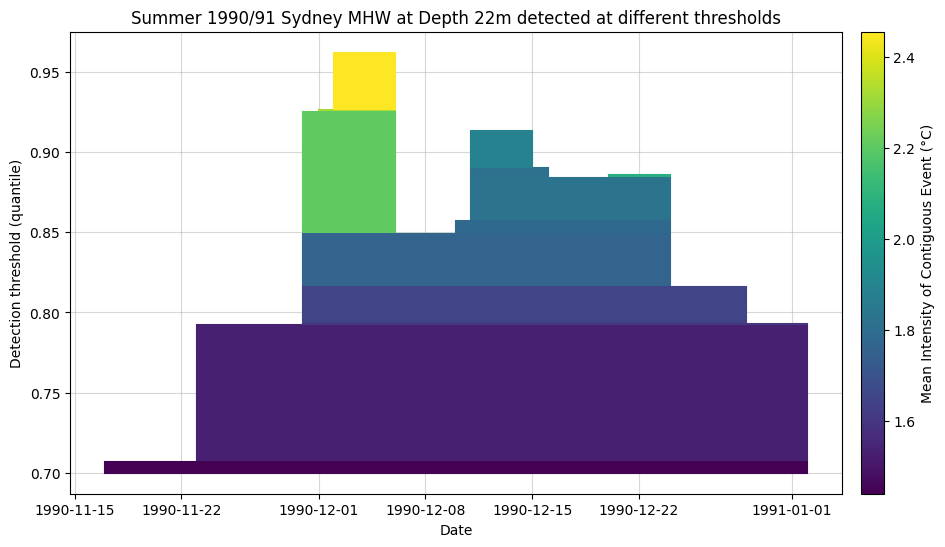

In [ ]:
method = "quantile"
depth = 22

selected_mhw_events = (
    mhw_events_catalogue
    .xs(method, level="threshold_method")
    .xs(depth, level="depth")
    .reset_index()
)
mhw_1990 = selected_mhw_events.loc[selected_mhw_events['start_date'].dt.year == 1990]

fig, ax = plt.subplots(figsize=(12, 6))
plt.grid(alpha=0.5)
for i in range(len(mhw_1990)):
    row = mhw_1990.iloc[i]
    norm = plt.Normalize(vmin=mhw_1990.mean_intensity.min(), vmax=mhw_1990.mean_intensity.max())
    cmap = plt.cm.viridis
    ax.plot(
        [row.start_date, row.end_date], 
        [row.threshold_value, row.threshold_value],
        color=cmap(norm(row.mean_intensity)))
ax.cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap), 
    ax=ax, pad=0.02,
    label='Mean Intensity of Contiguous Event (°C)')
ax.set_xlabel("Date")
ax.set_ylabel(f"Detection threshold ({method})")
ax.set_title("Summer 1990/91 Sydney MHW at Depth 22m detected at different thresholds")

## Plot of Empirical Annual Exceedance Probability, and Return Period, of MHW Duration

### How these figures were made
1. Set a percentile exeedance threshold
2. From the dataset of MHW events at 22m depth, select the exceedance events for the threshold over the entire time period (34 years)
3. For each duration $d$ between the minimum and maximum for the observed events, iterate over all years
4. Count the number of years in which there is an event of at least duration $d$
5. Divide the number of years with qualifying events by the number of years with threshold exceedance events (even ones that do not qualify)

### What these figures show mathematically

Probability of any year containing an MHW of duration at least $d$ days, given its minumim temperature $T_{min}$ surpasses the specified threshold $q$ $$\mathbb{P}(D \ge d | T_{{min}} \geq q)$$

and the associated return period is obtained by inverting the exceedance probability $$T_{d,q} = 1/\mathbb{P}(D \ge d | T_{{min}} \geq q).$$

The annual probability is estimated by $$\hat{\mathbb{P}}(D \ge d | T_{{min}} \geq q) \simeq \frac{\# \text{years with qualifying events}}{\# \text{years with exceedance events}}.$$ 

### What these figures tell us

- As the detection threshold is increased, the duration of events generally gets shorter, as expected
- Annual probability of MHW duration seems geometrically/exponentially distributed; it is the number of qualifying events occurring over the record
- The shortest event (most common) also gets less likely, as fewer qualifying event occur in the record (fewer and fewer than 1/year)
    - Peak duration exceedance probabilities are much less than 1 since the most likely events exceeding the threshold are shorter than the minimum event duration

### Analogies in literature

- 

In [6]:
pc = 0.82

mhws_pc90_d22 = mhw_events_20m.loc[mhw_events_20m['percentile']==pc]

durations = np.sort(mhws_pc90_d22.duration.unique())
years = mhws_pc90_d22.start_date.dt.year.unique()

results = pd.DataFrame(columns=['duration', 'probability'])
for d in durations:
    counter = 0
    for yr in years:
        if mhws_pc90_d22.loc[mhws_pc90_d22['start_date'].dt.year==yr].duration.max() >= d:
            counter += 1
    results = pd.concat([results, pd.DataFrame({'duration': [d], 'probability': [counter / 34]})], ignore_index=True)

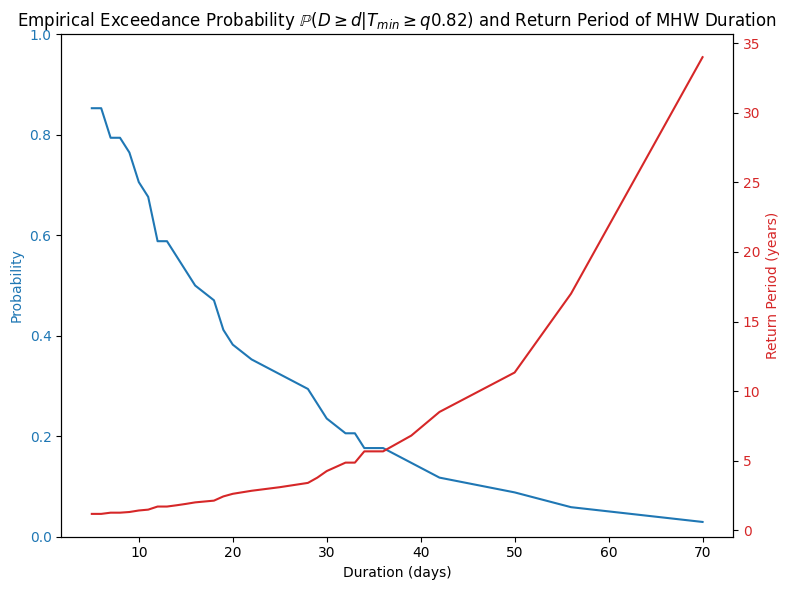

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 6))

color = 'tab:blue'
ax1.plot(results['duration'], results['probability'], color=color)
ax1.set_xlabel("Duration (days)")
ax1.set_ylabel("Probability", color=color)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Return Period (years)', color=color)
ax2.plot(results['duration'], np.divide(1, results['probability']), color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_title(f"Empirical Exceedance Probability $\mathbb{{P}}(D \geq d | T_{{min}} \geq q{pc})$ and Return Period of MHW Duration")

fig.tight_layout()

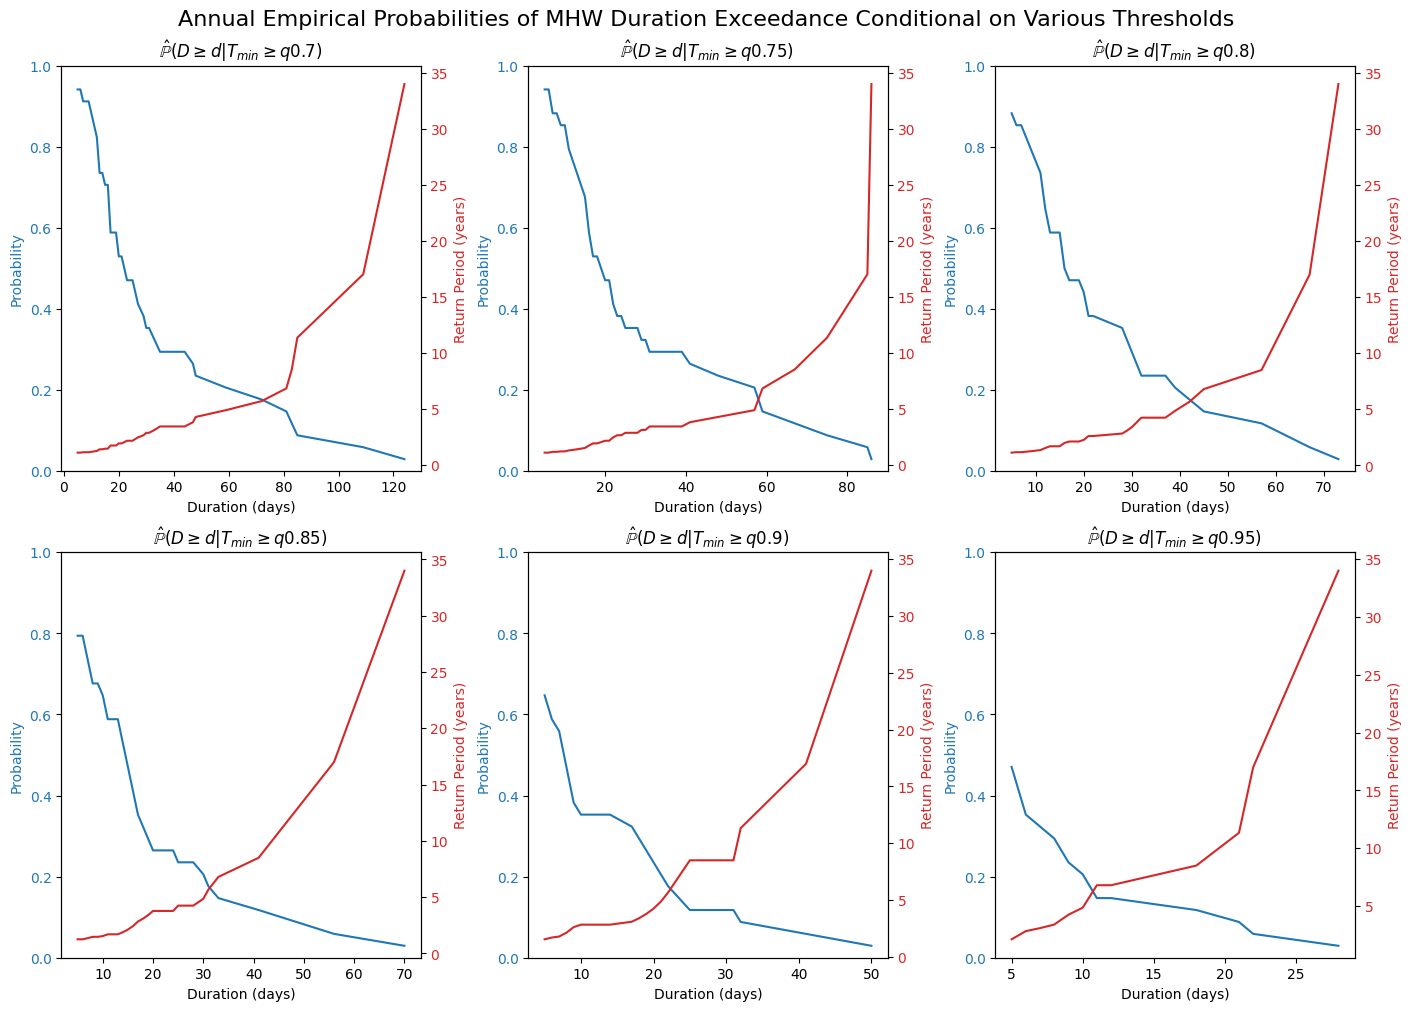

In [8]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

results = pd.DataFrame(columns=['percentile', 'duration', 'probability'])

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events_20m.loc[(np.isclose(mhw_events_20m["percentile"], p))]
    
    durations = np.sort(mhw_events_20m_p.duration.unique())
    years = mhw_events_20m_p.start_date.dt.year.unique()

    for d in durations:
        counter = 0
        for yr in years:
            if mhw_events_20m_p.loc[mhw_events_20m_p['start_date'].dt.year==yr].duration.max() >= d:
                counter += 1
        results = pd.concat([results, pd.DataFrame({'percentile': p, 'duration': [d], 'probability': [counter / 34]})], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = results[results['percentile'] == p]

    color = 'tab:blue'
    ax.plot(data['duration'], data['probability'], color=color)
    ax.set_xlabel("Duration (days)")
    ax.set_ylabel("Probability", color=color)
    ax.set_title(f"$\hat{{\mathbb{{P}}}}(D \geq d | T_{{min}} \geq q{p})$ ")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelcolor=color)

    ax2 = ax.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Return Period (years)', color=color)
    ax2.plot(data['duration'], np.divide(1, data['probability']), color=color)
    ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle("Annual Empirical Probabilities of MHW Duration Exceedance Conditional on Various Thresholds", fontsize=16,)

plt.show()

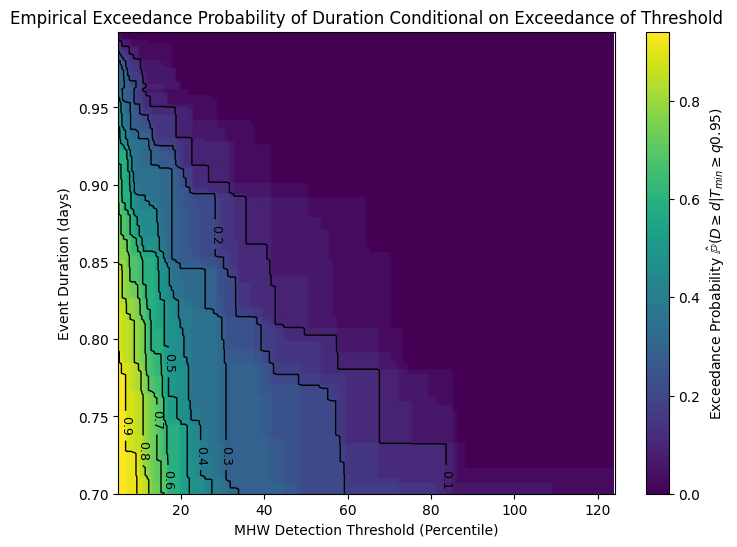

In [9]:
## Jordan written code: proc time 3m 14s

mhw_events_20m #.loc[(np.isclose(mhw_events_20m["percentile"], p))]
    
dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
all_durations = range(dur_min, dur_max + 1)
n_durations = len(all_durations)
all_percentiles = np.sort(mhw_events_20m.percentile.unique())
n_percentiles = len(all_percentiles)

results = np.zeros((n_percentiles, n_durations))

for i in list(range(n_durations))[::-1]:
    d = all_durations[i]
    for j in range(n_percentiles):

        mhw_events_20m_p = mhw_events_20m.loc[(np.isclose(mhw_events_20m["percentile"], all_percentiles[j]))]
        durations = np.sort(mhw_events_20m_p.duration.unique())
        years = mhw_events_20m_p.start_date.dt.year.unique()

        counter = 0
        for yr in years:
            if mhw_events_20m_p.loc[mhw_events_20m_p['start_date'].dt.year==yr].duration.max() >= d:
                counter += 1
        
        results[j, i] = np.divide(counter, 34)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[dur_min, dur_max, all_percentiles[0], all_percentiles[-1]], cmap='viridis')
contours = ax.contour(all_durations, all_percentiles, results, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9)#, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Event Duration (days)")
ax.set_title("Empirical Exceedance Probability of Duration Conditional on Exceedance of Threshold")
ax.figure.colorbar(ax.images[0], label=f"Exceedance Probability $\hat{{\mathbb{{P}}}}(D \geq d | T_{{min}} \geq q{p})$ ")

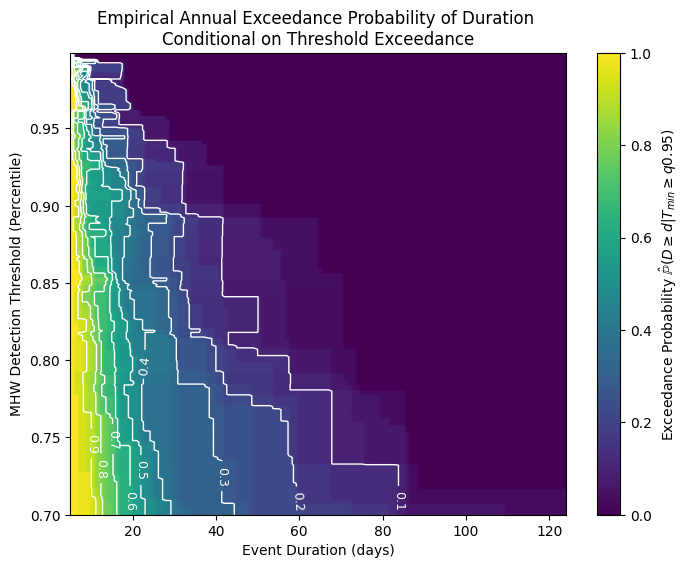

In [17]:
## ChatGPT improved code: proc time 0.2s

# Add year
df = mhw_events_20m.copy()
df["year"] = df["start_date"].dt.year

# Maximum MHW duration in each year for each percentile
annual_max = (
    df.groupby(["percentile", "year"])["duration"]
      .max()
      .unstack("year")
)

# Percentiles and durations
all_percentiles = np.sort(df["percentile"].unique())
dur_min = int(df["duration"].min())
dur_max = int(df["duration"].max())
all_durations = np.arange(dur_min, dur_max + 1)

# Make sure rows are in percentile order
annual_max = annual_max.reindex(all_percentiles)

# Convert to numpy
annual_max_values = annual_max.to_numpy()

# Compare every annual max duration against every duration threshold
# Shape:
#   annual_max_values[:, :, None] -> percentile x year x 1
#   all_durations[None, None, :]  -> 1 x 1 x duration
exceedances = (
    annual_max_values[:, :, None] >= all_durations[None, None, :]
)

# Count years exceeding each duration
counter = exceedances.sum(axis=1)

# Number of years with any event at each percentile
threshold_exceedance_years = np.sum(
    ~np.isnan(annual_max_values),
    axis=1
)

# Probability of exceedance conditional
results = counter / threshold_exceedance_years[:, None]

# Probability of exceedance
# n_years = annual_max.shape[1]
# results = counter / n_years

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[dur_min, dur_max, all_percentiles[0], all_percentiles[-1]], cmap='viridis')
contours = ax.contour(all_durations, all_percentiles, results, 
                        levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], colors='white', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9)#, fmt='%.1f')
ax.set_ylabel("MHW Detection Threshold (Percentile)")
ax.set_xlabel("Event Duration (days)")
ax.set_title("Empirical Annual Exceedance Probability of Duration \nConditional on Threshold Exceedance")
ax.figure.colorbar(ax.images[0], label=f"Exceedance Probability $\hat{{\mathbb{{P}}}}(D \geq d | T_{{min}} \geq q{p})$ ")

## Plot of Empirical Annual Joint Exceedance Probability and Return Period of MHW Duration and Quantile Threshold

### How these figures were made
1. Set a percentile exeedance threshold
2. From the dataset of MHW events at 22m depth, select the exceedance events for the threshold over the entire time period (34 years)
3. For each duration $d$ between the minimum and maximum for the observed events, iterate over all years
4. Count the number of years in which there is an event of at least duration $d$
5. Divide the number of years with qualifying events by the total number of years

### What these figures show mathematically

Probability of any year containing an MHW of duration at least $d$ days and with minumim temperature $T_{min}$ surpassing the specified threshold $q$ $$\mathbb{P}(D \ge d, T_{{min}} \geq q)$$

and the associated return period is obtained by inverting the exceedance probability $$T_{d,q} = 1/\mathbb{P}(D \ge d , T_{{min}} \geq q).$$

The annual probability is estimated by $$\hat{\mathbb{P}}(D \ge d, T_{{min}} \geq q) \simeq \frac{\# \text{years with qualifying events}}{\# \text{years}}$$ 

for $d \in \{ 5,6,...,124 \}$ and $q \in \{q_p : p=0.7,0.701,...,0.999\}.$

### What these figure tells us

- Compared to the conditional duration exceedance probability plot above:
    - Lower probability values for joint exceedance events in the lower left quadrant (shorter and less intense events), compared to the conditional duration exceedance probability
    - Similar probability values for extreme events (in both duration and "mininum intensity") probably reflect a lack of event data as opposed to near equality of conditional and joint probabilities

### Analogies in literature

- Figure 11 in "Return period of bivariate distributed extreme hydrological events" (Shiau, 2003)
    - Shows annual joint return period of a flood based on flood volume (mean intensity) and flood peak (max intensity)

![Joint RP of flood volume and peak](./images/jointRP_flood_vol_peak.png)

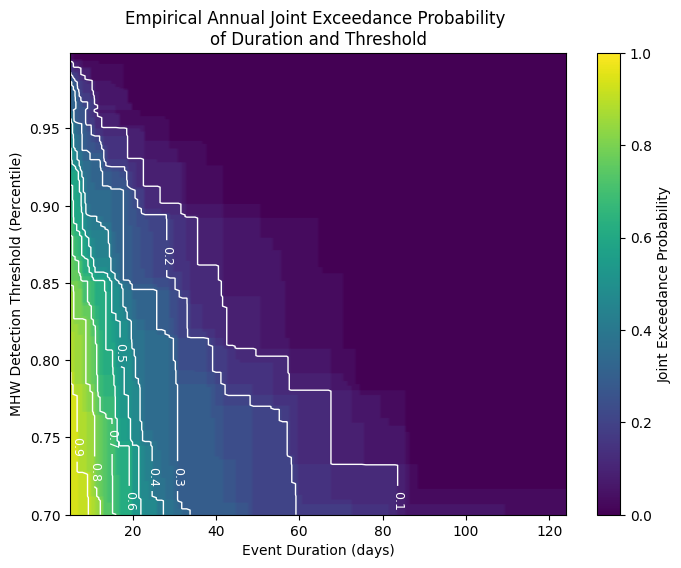

In [19]:
df = mhw_events_20m.copy()

# add start date of MHW events
df["year"] = df["start_date"].dt.year
# get list of all percentiles and durations
all_percentiles = np.sort(df["percentile"].unique())
dur_min, dur_max = int(df["duration"].min()), int(df["duration"].max())
all_durations = np.arange(dur_min, dur_max + 1)

# Maximum event duration in each year for each exact percentile
annual_max_duration_by_pc = (
    df.groupby(["year", "percentile"])["duration"]
    .max()
    .unstack("percentile")
    .reindex(columns=all_percentiles)
)

# For each year and percentile p, 
# max duration of any event with percentile >= p using cumulative maximum
annual_max_duration_threshold = (
    annual_max_duration_by_pc
    .reindex(columns=all_percentiles[::-1])
    .cummax(axis=1)
    .reindex(columns=all_percentiles)
)

# Boolean array of duration > d for every year, percentile and duration
# [:, :, None] adds new dimension to array so 
# annual_max_duration_threshold (34, 300) → (34, 300, 1)
# and all_durations (120,) → (1, 1, 120)
# numpy broadcasts dims of size 1 automatically
joint_exceedances = annual_max_duration_threshold.to_numpy()[:, :, None] >= all_durations[None, None, :]

# Annual joint exceedance probability: sum over all years and divide by total # years
# to get array with shape (percentiles, durations)
joint_probability = joint_exceedances.sum(axis=0) / 34

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(joint_probability, aspect='auto', origin='lower', extent=[dur_min, dur_max, all_percentiles[0],\
    all_percentiles[-1]], cmap='viridis', vmin=0, vmax=1)
contours = ax.contour(all_durations, all_percentiles, joint_probability, 
                        levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], colors='white', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9)#, fmt='%.1f')
ax.set_ylabel("MHW Detection Threshold (Percentile)")
ax.set_xlabel("Event Duration (days)")
ax.set_title("Empirical Annual Joint Exceedance Probability \nof Duration and Threshold")
ax.figure.colorbar(ax.images[0], label=f"Joint Exceedance Probability") #$\hat{{\mathbb{{P}}}}(D \geq d, T_{{min}} \geq q{p})$ ")

/var/folders/9w/k0h7t6v903j1bv4zt40nlrm80000gn/T/ipykernel_90639/1766286519.py:2: RuntimeWarning: divide by zero encountered in divide
  joint_rp = np.divide(1, joint_probability)


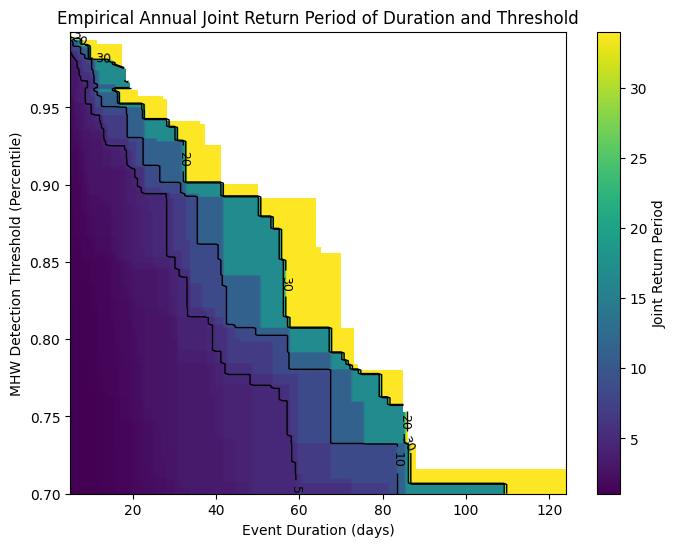

In [20]:
# return period
joint_rp = np.divide(1, joint_probability)
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(joint_rp, aspect='auto', origin='lower', extent=[dur_min, dur_max, all_percentiles[0],\
    all_percentiles[-1]], cmap='viridis')
contours = ax.contour(all_durations, all_percentiles, joint_rp, levels=[5,10,20,30], colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9)#, fmt='%.1f')
ax.set_ylabel("MHW Detection Threshold (Percentile)")
ax.set_xlabel("Event Duration (days)")
ax.set_title("Empirical Annual Joint Return Period of Duration and Threshold")
ax.figure.colorbar(ax.images[0], label=f"Joint Return Period")# $1/\hat{{\mathbb{{P}}}}(D \geq d, T_{{min}} \geq q{p})$ ")

## Plot of Empirical Annual Exceedance Probability of MHW Mean Intensity

### How these figures were made
1. Set a percentile exeedance threshold
2. From the dataset of MHW events at 22m depth, select the exceedance events over the entire time period (34 years)
3. For each duration $d$ between the minimum and maximum for the observed events, iterate over all years
4. Count the number of years in which there is an event of at least duration $d$
5. Divide the number of years with qualifying events by the total number of years (34)

### What this figure shows

Probability of any year containing an MHW of mean intensity at least $m \degree C$ , given its minumim temperature $T_{min}$ surpasses the specified threshold $q$

$$\mathbb{P}(M \ge m | T_{{min}} \geq q)$$

Empirically estimated by $$\hat{\mathbb{P}}(M \ge m | T_{{min}} \geq q) \simeq \frac{\# \text{years with qualifying events}}{\# \text{years}}$$

In [13]:
pc = 0.82

mhws_pc90_d22 = mhw_events_20m.loc[mhw_events_20m['percentile']==pc]

mean_intensities = np.linspace(mhws_pc90_d22.mean_intensity.min(), mhws_pc90_d22.mean_intensity.max(), 100)
years = mhws_pc90_d22.start_date.dt.year.unique()

results = pd.DataFrame(columns=['mean_intensity', 'probability'])
for m in mean_intensities:
    counter = 0
    for yr in years:
        if mhws_pc90_d22.loc[mhws_pc90_d22['start_date'].dt.year==yr].mean_intensity.max() >= m:
            counter += 1
    results = pd.concat([results, pd.DataFrame({'mean_intensity': [m], 'probability': [counter / 34]})], ignore_index=True)

Text(0.5, 1.0, 'Annual Probability of MHW Mean Intensity Exceedance $\\hat{\\mathbb{P}}(M \\geq m | T_{min} \\geq 0.82)$ ')

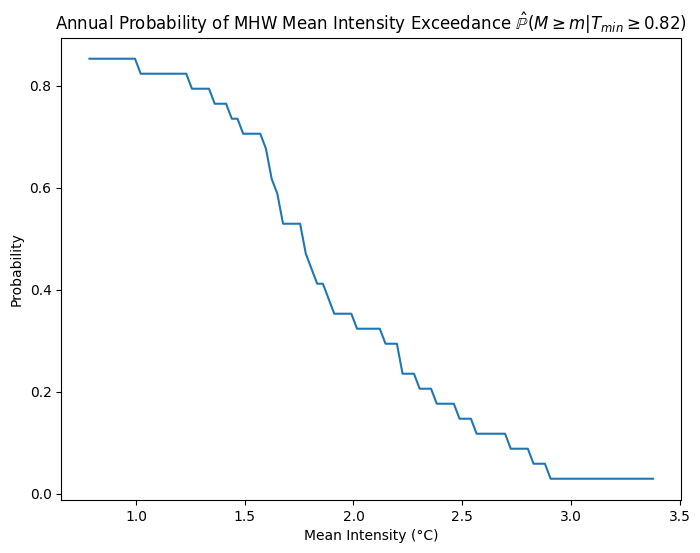

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(results['mean_intensity'], results['probability'])
ax.set_xlabel("Mean Intensity (°C)")
ax.set_ylabel("Probability")
ax.set_title(f"Annual Probability of MHW Mean Intensity Exceedance $\hat{{\mathbb{{P}}}}(M \geq m | T_{{min}} \geq {pc})$ ")

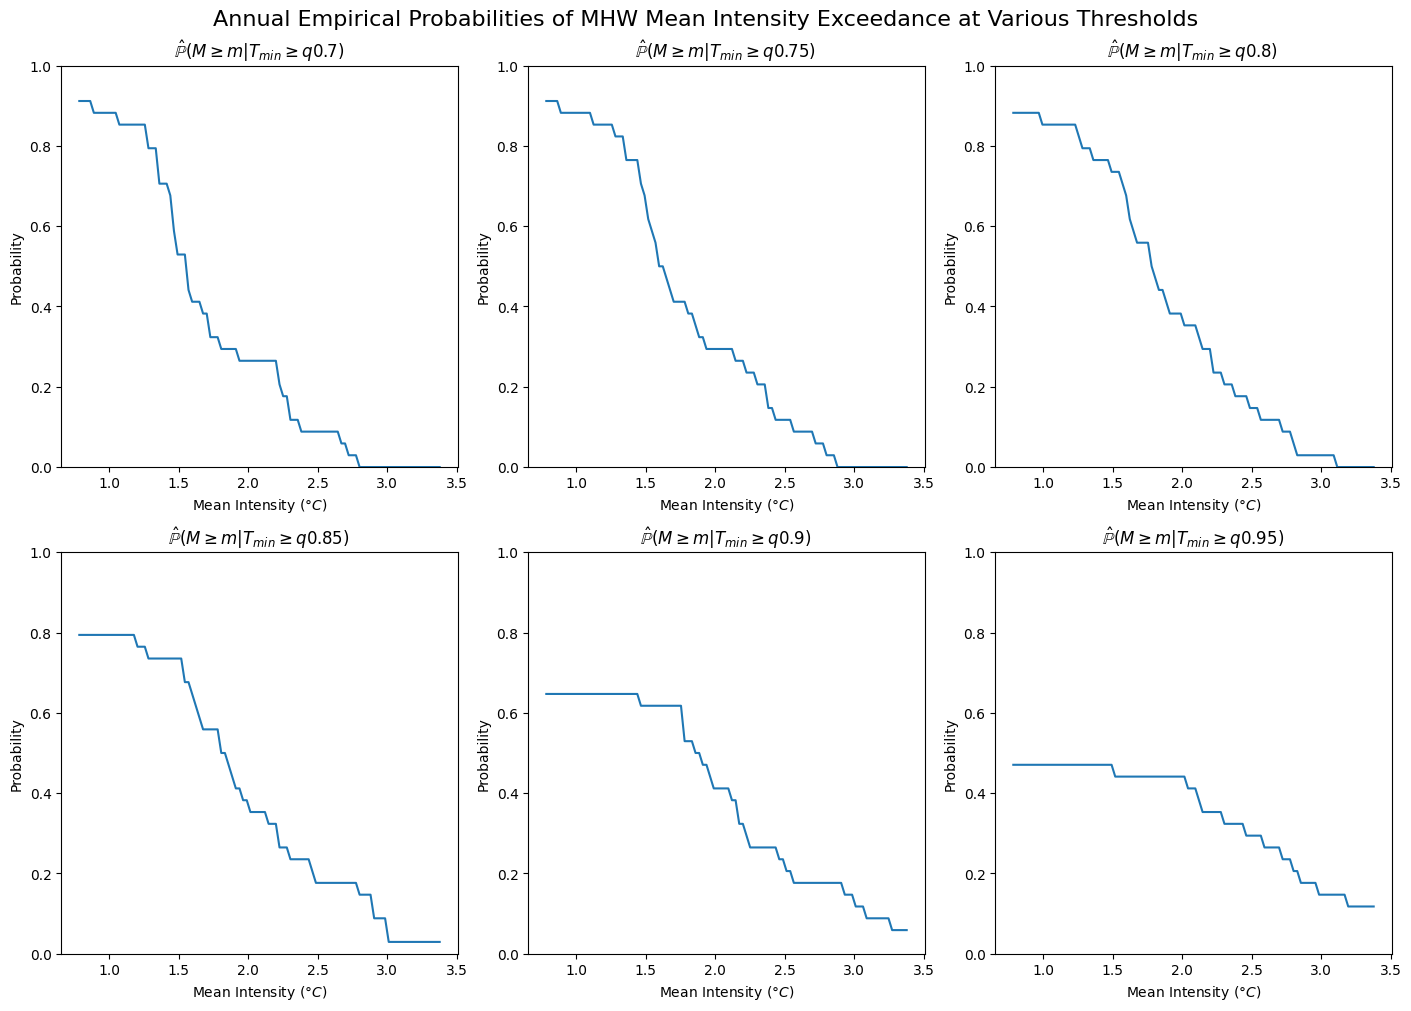

In [15]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

results = pd.DataFrame(columns=['percentile', 'mean_intensity', 'probability'])

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events_20m.loc[(np.isclose(mhw_events_20m["percentile"], p))]
    
    mean_intensities = np.linspace(mhws_pc90_d22.mean_intensity.min(), mhws_pc90_d22.mean_intensity.max(), 100)
    years = mhw_events_20m_p.start_date.dt.year.unique()

    for m in mean_intensities:
        counter = 0
        for yr in years:
            if mhw_events_20m_p.loc[mhw_events_20m_p['start_date'].dt.year==yr].mean_intensity.max() >= m:
                counter += 1
        results = pd.concat([results, pd.DataFrame({'percentile': p, 'mean_intensity': [m], 'probability': [counter / 34]})], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)


mean_intensities = np.linspace(mhws_pc90_d22.mean_intensity.min(), mhws_pc90_d22.mean_intensity.max(), 100)
years = mhws_pc90_d22.start_date.dt.year.unique()

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = results[results['percentile'] == p]

    ax.plot(data['mean_intensity'], data['probability'])
    ax.set_xlabel("Mean Intensity $(°C)$")
    ax.set_ylabel("Probability")
    ax.set_title(f"$\hat{{\mathbb{{P}}}}(M \geq m | T_{{min}} \geq q{p})$ ")
    ax.set_ylim(0, 1)

fig.suptitle("Annual Empirical Probabilities of MHW Mean Intensity Exceedance at Various Thresholds", fontsize=16,)

plt.show()

## Plot of Empirical Return Period of MHW Duration at a Given Threshold

In [16]:
prob_lvls = False

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls
yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()

dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
all_durations = range(dur_min, dur_max + 1)
n_durations = len(all_durations)
results = np.zeros((n_durations, len(percentiles)))
for i in list(range(n_durations))[::-1]:
    for j in range(len(percentiles)):
        filtered = mhw_events_20m[(mhw_events_20m['duration']>=all_durations[i]) & (mhw_events_20m['percentile']==percentiles[j])]
            ## (Duration-weighted) Prob of being in event of at least this duration, given threshold, given in an event
        # results[i, j] = filtered['duration'].sum() / mhw_events_20m.duration.sum()
            ## Prob of being in event of at least this duration, given threshold, given in an event
        # results[i, j] = len(filtered) / len(mhw_events_20m)
            ## 
        # interarrival_time = filtered['start_date'].diff().dt.days.mean() / 365.25
            ## Return period in years for events of at least this duration, given threshold
        results[i, j] = np.divide(yrs, len(filtered))

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[percentiles[0], percentiles[-1], dur_min, dur_max], cmap='viridis')
contours = ax.contour(percentiles, all_durations, results, levels=lvls, colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Event Duration (days)")
# ax.set_title("Empirical Return Period of Duration for a Given Threshold")
ax.figure.colorbar(ax.images[0], label='Return Period (years)')

NameError: name 'percentiles' is not defined

## Plot of Empirical Exceedance Probability of MHW Duration at a Given Threshold

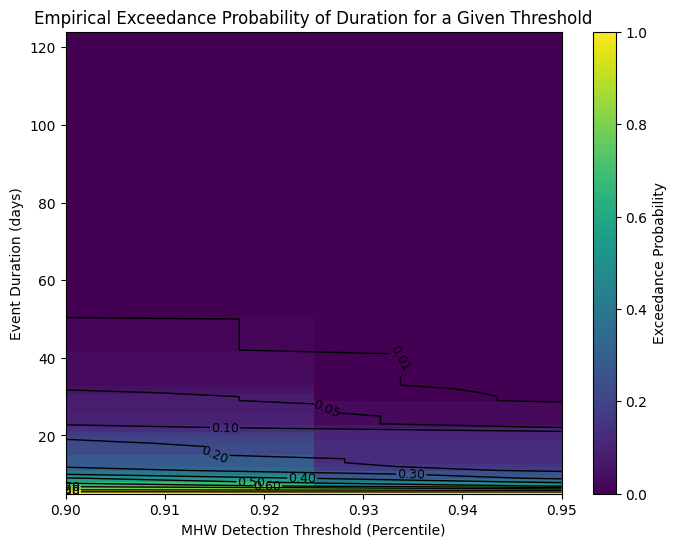

In [ ]:
prob_lvls = True

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls
yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()

dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
all_durations = range(dur_min, dur_max + 1)
n_durations = len(all_durations)
results = np.zeros((n_durations, len(percentiles)))
for i in list(range(n_durations))[::-1]:
    for j in range(len(percentiles)):
        filtered = mhw_events_20m[(mhw_events_20m['duration']>=all_durations[i]) & (mhw_events_20m['percentile']==percentiles[j])]
        filtered2 = mhw_events_20m[(mhw_events_20m['percentile']==percentiles[j])]
            ## (Duration-weighted) Prob of being in event of at least this duration, given threshold, given in an event
        # results[i, j] = filtered['duration'].sum() / mhw_events_20m.duration.sum()
            ## Prob of being in event of at least this duration, given threshold, given in an event
        # results[i, j] = len(filtered) / len(mhw_events_20m)
            ## 
        # interarrival_time = filtered['start_date'].diff().dt.days.mean() / 365.25
            ## Return period in years for events of at least this duration, given threshold
        # results[i, j] = np.divide(len(filtered), yrs)/len(filtered2)
        results[i, j] = np.divide(len(filtered), len(filtered2))

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[percentiles[0], percentiles[-1], dur_min, dur_max], cmap='viridis')
contours = ax.contour(percentiles, all_durations, results, levels=lvls, colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9)#, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Event Duration (days)")
ax.set_title("Empirical Exceedance Probability of Duration for a Given Threshold")
ax.figure.colorbar(ax.images[0], label='Exceedance Probability')

## Plot of Empirical Return Period of MHW Max Intensity at a Given Threshold

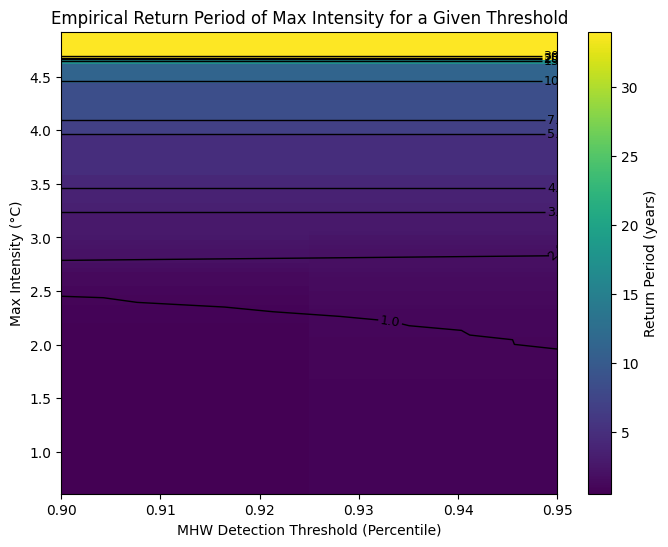

In [ ]:
prob_lvls = False

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls
yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()

max_int_min, max_int_max = mhw_events_20m.max_intensity.min(), mhw_events_20m.max_intensity.max()
all_ints = np.linspace(max_int_min, max_int_max, 100)
n_ints = len(all_ints)
results = np.zeros((n_ints, len(percentiles)))
for i in list(range(n_ints))[::-1]:
    for j in range(len(percentiles)):
        filtered = mhw_events_20m[(mhw_events_20m['max_intensity']>=all_ints[i]) & (mhw_events_20m['percentile']==percentiles[j])]
        # results[i, j] = filtered['duration'].sum() / mhw_events_20m.duration.sum()
        # results[i, j] = 1- (len(filtered) / len(mhw_events_20m))
            ## Return period in years for event of at least this max intensity, given threshold
        results[i, j] = np.divide(yrs, len(filtered)) 

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[percentiles[0], percentiles[-1], max_int_min, max_int_max], cmap='viridis')
contours = ax.contour(percentiles, all_ints, results, levels=lvls, colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Max Intensity (°C)")
ax.set_title("Empirical Return Period of Max Intensity for a Given Threshold")
ax.figure.colorbar(ax.images[0], label='Return Period (years)')

## Plot of Empirical Exceedance Probability of MHW Max Intensity at a Given Threshold

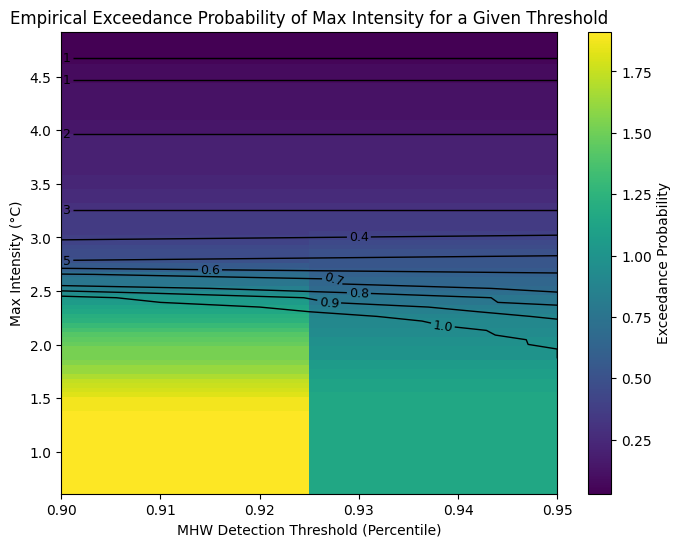

In [ ]:
prob_lvls = True

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls
yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()

max_int_min, max_int_max = mhw_events_20m.max_intensity.min(), mhw_events_20m.max_intensity.max()
all_ints = np.linspace(max_int_min, max_int_max, 100)
n_ints = len(all_ints)
results = np.zeros((n_ints, len(percentiles)))
for i in list(range(n_ints))[::-1]:
    for j in range(len(percentiles)):
        filtered = mhw_events_20m[(mhw_events_20m['max_intensity']>=all_ints[i]) & (mhw_events_20m['percentile']==percentiles[j])]
        # results[i, j] = filtered['duration'].sum() / mhw_events_20m.duration.sum()
        # results[i, j] = 1- (len(filtered) / len(mhw_events_20m))
            ## Exceedance probability for event of at least this max intensity, given threshold
        results[i, j] = np.divide(len(filtered), yrs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[percentiles[0], percentiles[-1], max_int_min, max_int_max], cmap='viridis')
contours = ax.contour(percentiles, all_ints, results, levels=lvls, colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Max Intensity (°C)")
ax.set_title("Empirical Exceedance Probability of Max Intensity for a Given Threshold")
ax.figure.colorbar(ax.images[0], label='Exceedance Probability')

## Plot of Empirical Return Period of MHW Mean Intensity at a Given Threshold

/var/folders/9w/k0h7t6v903j1bv4zt40nlrm80000gn/T/ipykernel_24328/2357117841.py:25: RuntimeWarning: divide by zero encountered in divide
  results[i, j] = np.divide(yrs, len(filtered))


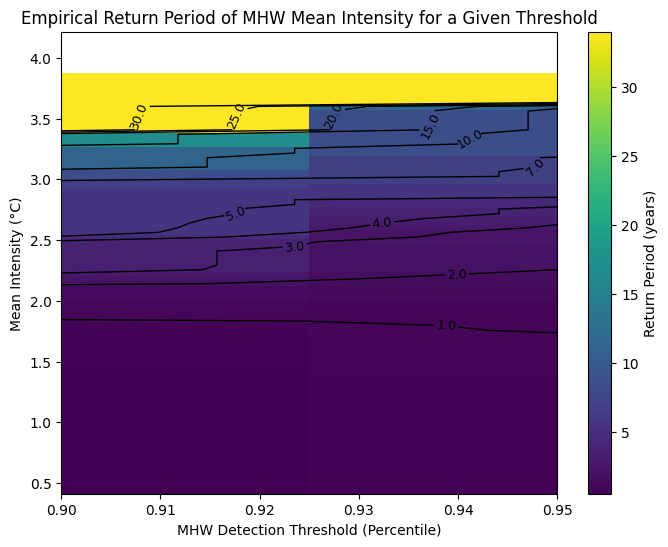

In [ ]:
prob_lvls = False

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls
yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()

mean_int_min, mean_int_max = mhw_events_20m.mean_intensity.min(), mhw_events_20m.mean_intensity.max()
all_ints = np.linspace(mean_int_min, mean_int_max, 100)
n_ints = len(all_ints)
results = np.zeros((n_ints, len(percentiles)))
for i in list(range(n_ints))[::-1]:
    for j in range(len(percentiles)):
        filtered = mhw_events_20m[(mhw_events_20m['mean_intensity']>=all_ints[i]) & (mhw_events_20m['percentile']==percentiles[j])]
        # results[i, j] = filtered['duration'].sum() / mhw_events_20m.duration.sum()
        # results[i, j] = 1- (len(filtered) / len(mhw_events_20m))
            ## Return period in years for event of at least this mean intensity, given threshold
        results[i, j] = np.divide(yrs, len(filtered)) 

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(results, aspect='auto', origin='lower', extent=[percentiles[0], percentiles[-1], mean_int_min, mean_int_max], cmap='viridis')
contours = ax.contour(percentiles, all_ints, results, levels=lvls, colors='black', linewidths=1)
ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')
ax.set_xlabel("MHW Detection Threshold (Percentile)")
ax.set_ylabel("Mean Intensity (°C)")
ax.set_title("Empirical Return Period of MHW Mean Intensity for a Given Threshold")
ax.figure.colorbar(ax.images[0], label='Return Period (years)')

## Plot of Empirical Return Periods for MHW Max Intensity and Duration (IDF Curves) for Various Thresholds

/var/folders/9w/k0h7t6v903j1bv4zt40nlrm80000gn/T/ipykernel_24328/2198498284.py:38: RuntimeWarning: divide by zero encountered in divide
  results[i, j] = np.divide(yrs, len(filtered))


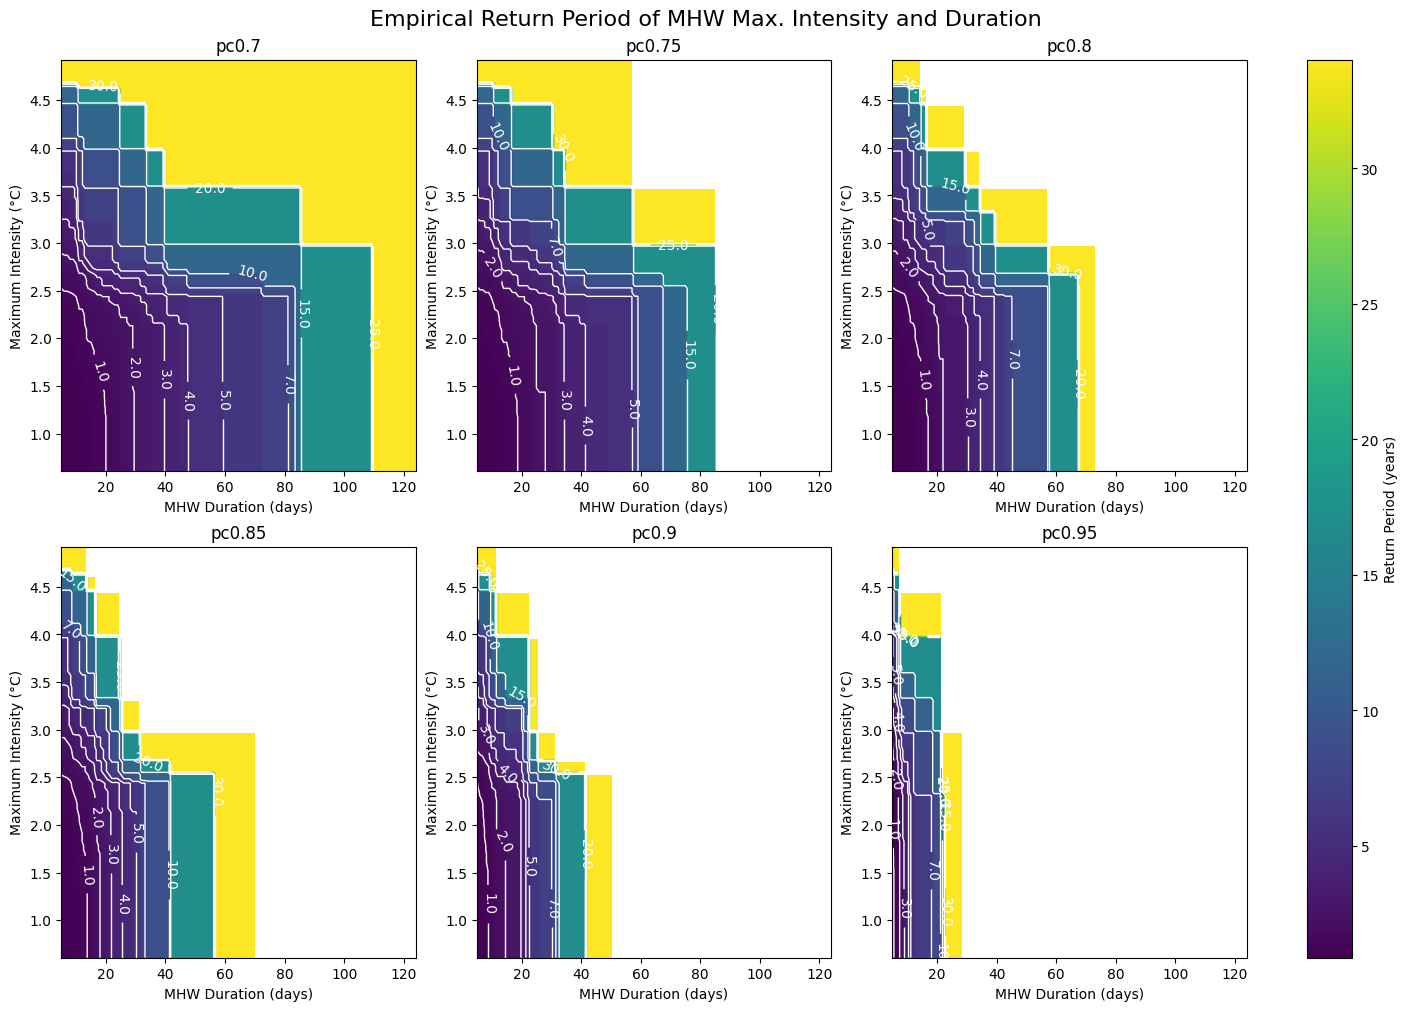

In [ ]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
prob_lvls = False

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls

plot_data = {}

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events_20m.loc[(np.isclose(mhw_events_20m["percentile"], p))]
    yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()
    # get iterable of durations
    dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
    all_durations = range(dur_min, dur_max + 1)
    n_durations = len(all_durations)
    # get iterable of intensities
    max_int_min, max_int_max = mhw_events_20m.max_intensity.min(), mhw_events_20m.max_intensity.max()
    all_ints = np.linspace(max_int_min, max_int_max, 100)
    n_ints = len(all_ints)
    # results matrix to plot
    results = np.zeros((n_ints, n_durations))

    for i in list(range(n_ints))[::-1]:
        for j in list(range(n_durations)):
            filtered = mhw_events_20m_p[(mhw_events_20m_p['max_intensity']>=all_ints[i]) & (mhw_events_20m_p['duration']>=all_durations[j])]
            # results[i, j] = filtered['duration'].sum() / mhw_events_20m_p.duration.sum()
            # results[i, j] = len(filtered) / len(mhw_events_20m_p)
                ## Return period in years for event of at least this max intensity and duration
            results[i, j] = np.divide(yrs, len(filtered))
    
    plot_data[p] = {
        "results": results,
        "durations": all_durations,
        "intensities": all_ints,
        "dur_min": dur_min,
        "dur_max": dur_max,
        "int_min": max_int_min,
        "int_max": max_int_max,
    }

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)

# Common colour scale
vmin = min(data["results"].min() for data in plot_data.values())
vmax = max(data["results"].max() for data in plot_data.values())

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = plot_data[p]

    im = ax.imshow(data["results"], aspect="auto", origin="lower",
        extent=[
            data["dur_min"],
            data["dur_max"],
            data["int_min"],
            data["int_max"],
        ],
        cmap="viridis", #vmin=vmin, vmax=vmax,
    )

    # Plot contours
    contours = ax.contour(data["durations"], data["intensities"], data["results"], levels=lvls, colors="white", linewidths=1,)
    ax.clabel(contours, inline=True, fontsize=10, fmt="%.1f")

    ax.set_title(f"pc{p:g}")
    ax.set_xlabel("MHW Duration (days)")
    ax.set_ylabel("Maximum Intensity (°C)")

fig.colorbar(im, ax=axes, label="Return Period (years)")
fig.suptitle("Empirical Return Period of MHW Max. Intensity and Duration", fontsize=16,)

plt.show()

## Plot of Empirical Exceedance Probability for MHW Max Intensity and Duration for Various Thresholds

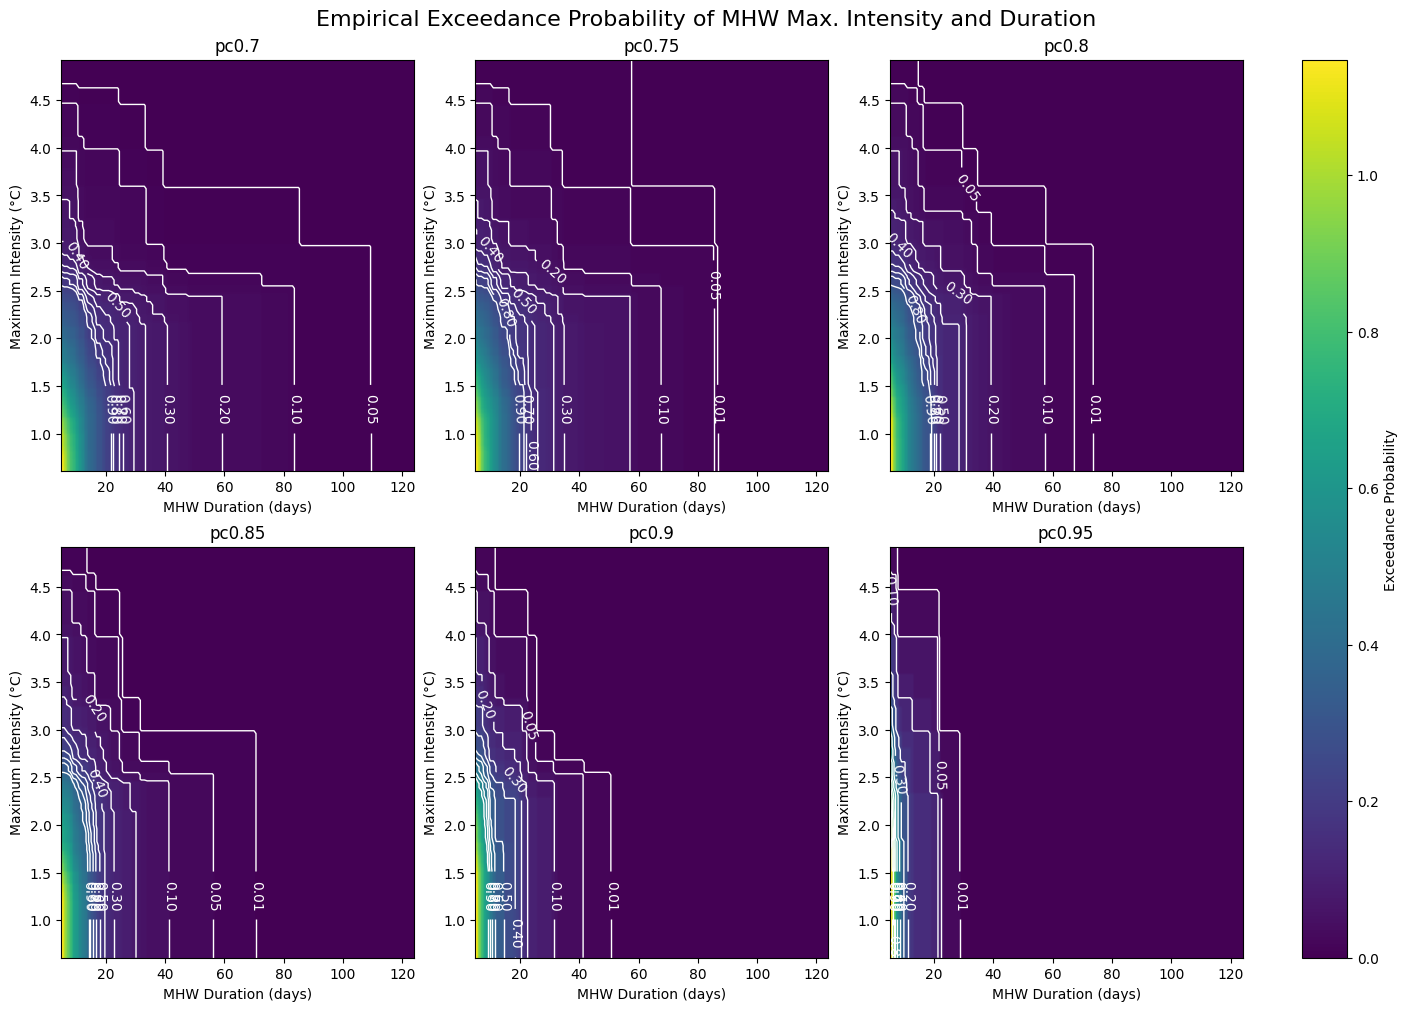

In [ ]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
prob_lvls = True

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]#+lvls

plot_data = {}

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events_20m.loc[(np.isclose(mhw_events_20m["percentile"], p))]
    yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()
    # get iterable of durations
    dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
    all_durations = range(dur_min, dur_max + 1)
    n_durations = len(all_durations)
    # get iterable of intensities
    max_int_min, max_int_max = mhw_events_20m.max_intensity.min(), mhw_events_20m.max_intensity.max()
    all_ints = np.linspace(max_int_min, max_int_max, 100)
    n_ints = len(all_ints)
    # results matrix to plot
    results = np.zeros((n_ints, n_durations))

    for i in list(range(n_ints))[::-1]:
        for j in list(range(n_durations)):
            filtered = mhw_events_20m_p[(mhw_events_20m_p['max_intensity']>=all_ints[i]) & (mhw_events_20m_p['duration']>=all_durations[j])]
            # results[i, j] = filtered['duration'].sum() / mhw_events_20m_p.duration.sum()
            # results[i, j] = len(filtered) / len(mhw_events_20m_p)
                ## Return period in years for event of at least this max intensity and duration
            results[i, j] = np.divide(len(filtered), yrs)
    
    plot_data[p] = {
        "results": results,
        "durations": all_durations,
        "intensities": all_ints,
        "dur_min": dur_min,
        "dur_max": dur_max,
        "int_min": max_int_min,
        "int_max": max_int_max,
    }

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)

# Common colour scale
vmin = min(data["results"].min() for data in plot_data.values())
vmax = max(data["results"].max() for data in plot_data.values())

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = plot_data[p]

    im = ax.imshow(data["results"], aspect="auto", origin="lower",
        extent=[
            data["dur_min"],
            data["dur_max"],
            data["int_min"],
            data["int_max"],
        ],
        cmap="viridis", #vmin=vmin, vmax=vmax,
    )

    # Plot contours
    contours = ax.contour(data["durations"], data["intensities"], data["results"], levels=lvls, colors="white", linewidths=1,)
    ax.clabel(contours, inline=True, fontsize=10)#, fmt="%.2f")

    ax.set_title(f"pc{p:g}")
    ax.set_xlabel("MHW Duration (days)")
    ax.set_ylabel("Maximum Intensity (°C)")

fig.colorbar(im, ax=axes, label="Exceedance Probability")
fig.suptitle("Empirical Exceedance Probability of MHW Max. Intensity and Duration", fontsize=16,)

plt.show()

## Plot of Empirical Return Periods for MHW Mean Intensity and Duration (IDF Curves) for Various Thresholds

/var/folders/9w/k0h7t6v903j1bv4zt40nlrm80000gn/T/ipykernel_55936/1882467006.py:34: RuntimeWarning: divide by zero encountered in divide
  results[i, j] = np.divide(yrs, len(filtered))


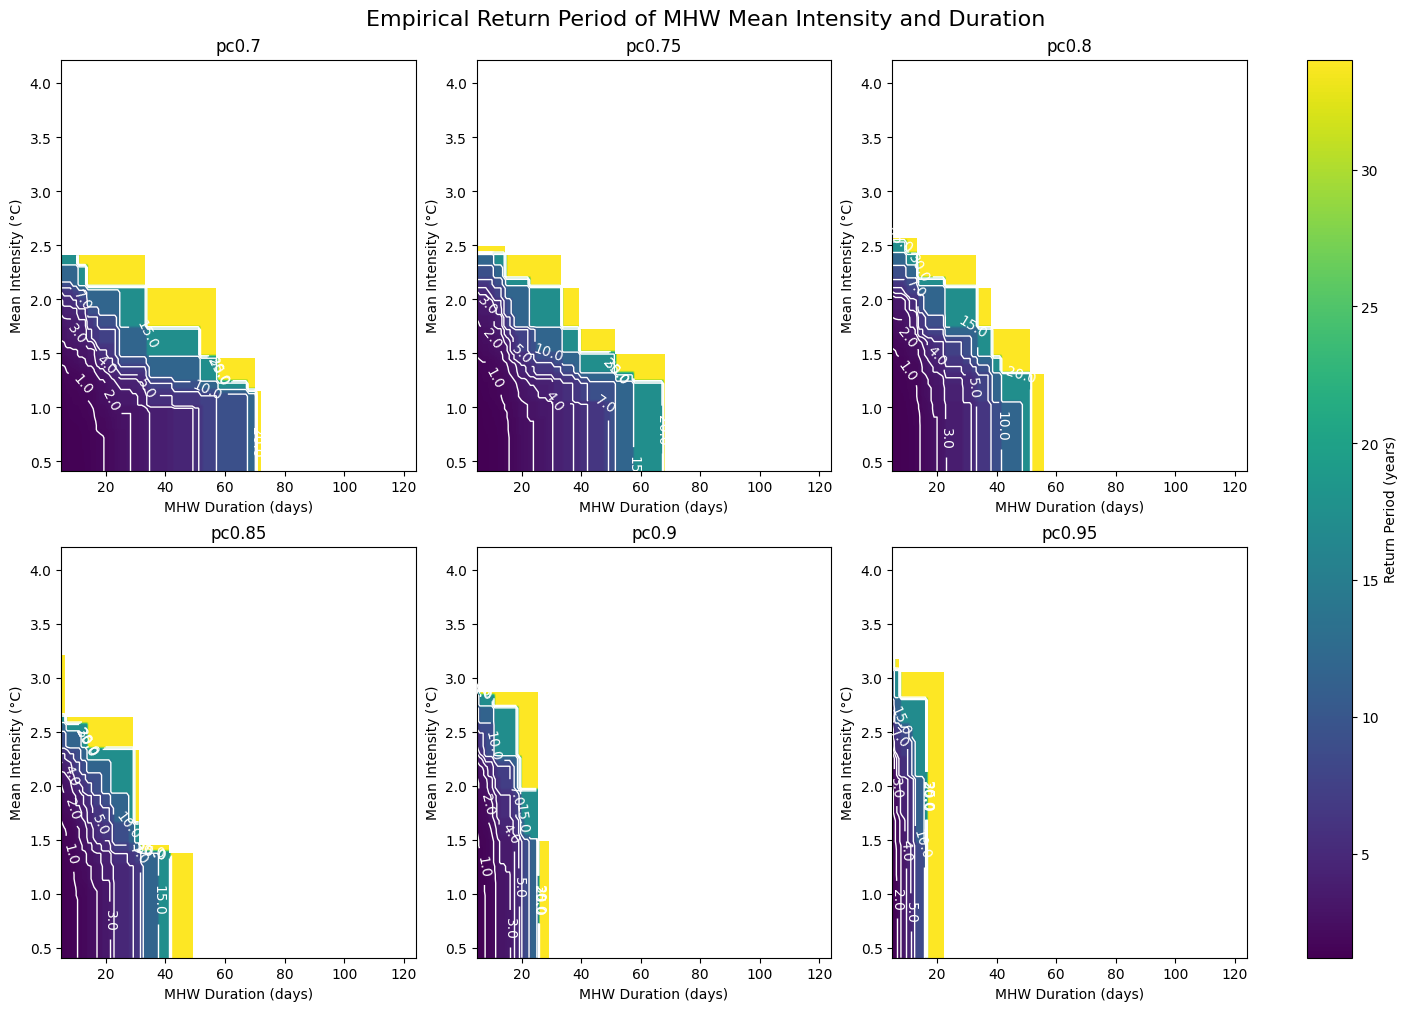

In [ ]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
prob_lvls = False

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls

plot_data = {}

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events.loc[(mhw_events['depth']==20) & (np.isclose(mhw_events["percentile"], p))]
    yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()
    # get iterable of durations
    dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
    all_durations = range(dur_min, dur_max + 1)
    n_durations = len(all_durations)
    # get iterable of intensities
    mean_int_min, mean_int_max = mhw_events_20m.mean_intensity.min(), mhw_events_20m.mean_intensity.max()
    all_ints = np.linspace(mean_int_min, mean_int_max, 100)
    n_ints = len(all_ints)
    # results matrix to plot
    results = np.zeros((n_ints, n_durations))

    for i in list(range(n_ints))[::-1]:
        for j in list(range(n_durations)):
            filtered = mhw_events_20m_p[(mhw_events_20m_p['mean_intensity']>=all_ints[i]) & (mhw_events_20m_p['duration']>=all_durations[j])]
            # results[i, j] = filtered['duration'].sum() / mhw_events_20m_p.duration.sum()
            # results[i, j] = len(filtered) / len(mhw_events_20m_p)
                ## Return period in years for event of at least this max intensity and duration
            results[i, j] = np.divide(yrs, len(filtered)) 
    
    plot_data[p] = {
        "results": results,
        "durations": all_durations,
        "intensities": all_ints,
        "dur_min": dur_min,
        "dur_max": dur_max,
        "int_min": mean_int_min,
        "int_max": mean_int_max,
    }

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)

# Common colour scale
vmin = min(data["results"].min() for data in plot_data.values())
vmax = max(data["results"].max() for data in plot_data.values())

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = plot_data[p]

    im = ax.imshow(data["results"], aspect="auto", origin="lower",
        extent=[
            data["dur_min"],
            data["dur_max"],
            data["int_min"],
            data["int_max"],
        ],
        cmap="viridis", #vmin=vmin, vmax=vmax,
    )

    # Plot contours
    contours = ax.contour(data["durations"], data["intensities"], data["results"], levels=lvls, colors="white", linewidths=1)
    ax.clabel(contours, inline=True, fontsize=10, fmt="%.1f")

    ax.set_title(f"pc{p:g}")
    ax.set_xlabel("MHW Duration (days)")
    ax.set_ylabel("Mean Intensity (°C)")

fig.colorbar(im, ax=axes, label="Return Period (years)")
fig.suptitle("Empirical Return Period of MHW Mean Intensity and Duration", fontsize=16,)

plt.show()

## Plot of Empirical Exceedance Probability for MHW Mean Intensity and Duration for Various Thresholds

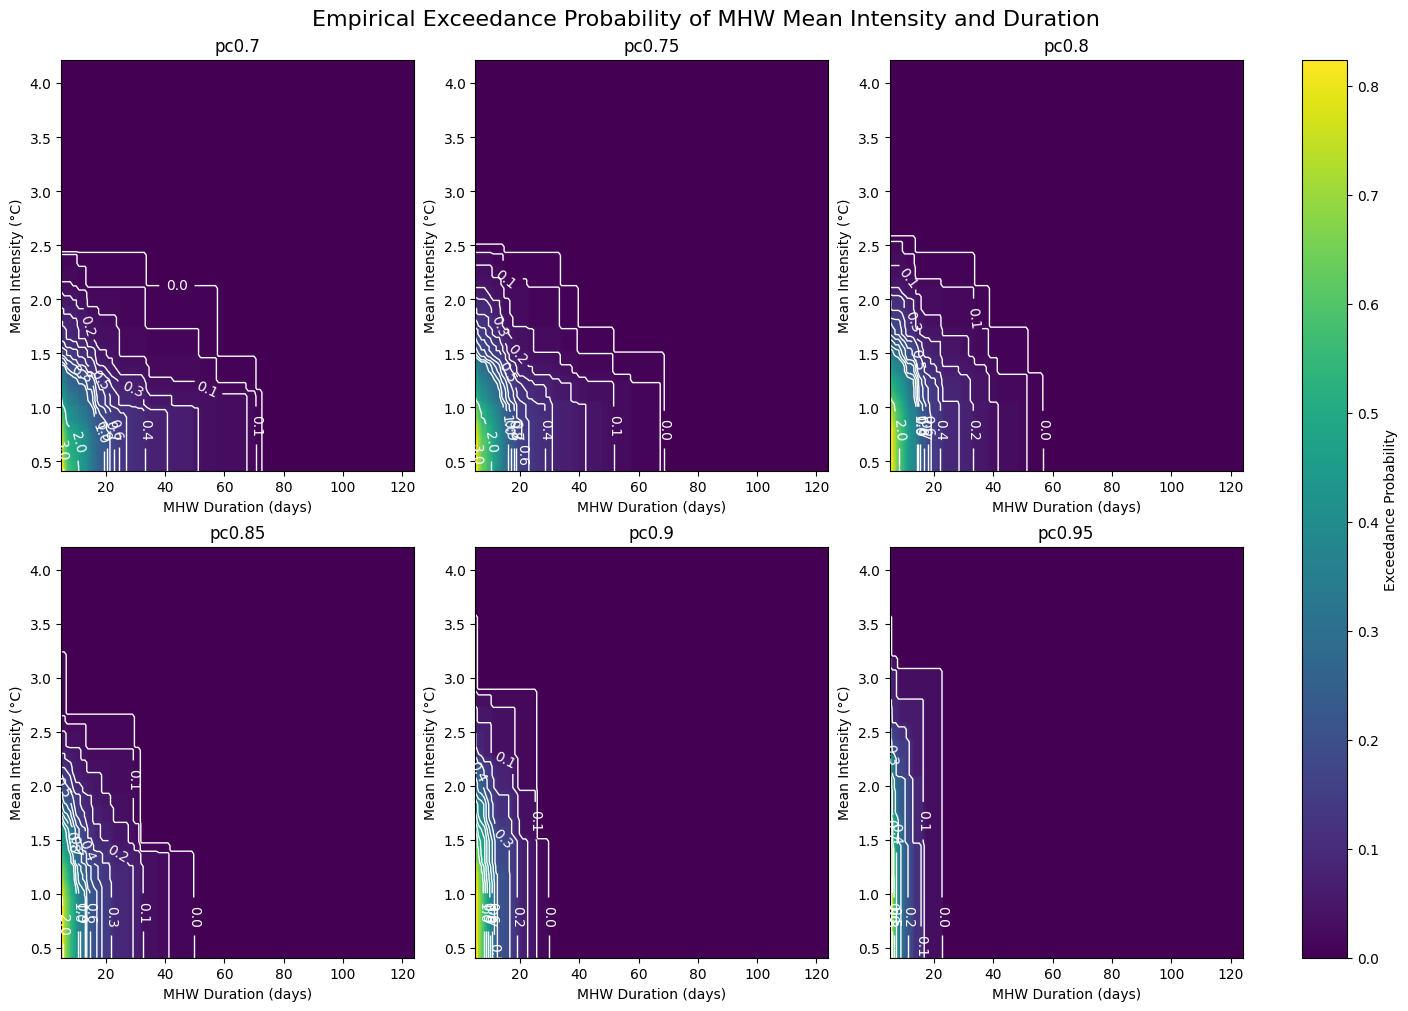

In [ ]:
percentiles_to_plot = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
prob_lvls = True

## ORS
mhw_events_20m = mhw_events_ors.loc[mhw_events_ors['depth']==22]
lvls = [1,2,3,4,5,7,10,15,20,25,30]

## IMOS
# mhw_events_20m = mhw_events.loc[mhw_events['depth']==20]
# lvls = [1,2,3,4,5,7,10,19]

if prob_lvls:
    lvls = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]+lvls

plot_data = {}

for p in percentiles_to_plot:

    mhw_events_20m_p = mhw_events.loc[(mhw_events['depth']==20) & (np.isclose(mhw_events["percentile"], p))]
    yrs = mhw_events_20m['start_date'].dt.year.max() - mhw_events_20m['start_date'].dt.year.min()
    # get iterable of durations
    dur_min, dur_max = int(mhw_events_20m.duration.min()), int(mhw_events_20m.duration.max())
    all_durations = range(dur_min, dur_max + 1)
    n_durations = len(all_durations)
    # get iterable of intensities
    mean_int_min, mean_int_max = mhw_events_20m.mean_intensity.min(), mhw_events_20m.mean_intensity.max()
    all_ints = np.linspace(mean_int_min, mean_int_max, 100)
    n_ints = len(all_ints)
    # results matrix to plot
    results = np.zeros((n_ints, n_durations))

    for i in list(range(n_ints))[::-1]:
        for j in list(range(n_durations)):
            filtered = mhw_events_20m_p[(mhw_events_20m_p['mean_intensity']>=all_ints[i]) & (mhw_events_20m_p['duration']>=all_durations[j])]
            # results[i, j] = filtered['duration'].sum() / mhw_events_20m_p.duration.sum()
            # results[i, j] = len(filtered) / len(mhw_events_20m_p)
                ## Return period in years for event of at least this max intensity and duration
            results[i, j] = np.divide(len(filtered), yrs)
    
    plot_data[p] = {
        "results": results,
        "durations": all_durations,
        "intensities": all_ints,
        "dur_min": dur_min,
        "dur_max": dur_max,
        "int_min": mean_int_min,
        "int_max": mean_int_max,
    }

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=False, sharey=False, constrained_layout=True)

# Common colour scale
vmin = min(data["results"].min() for data in plot_data.values())
vmax = max(data["results"].max() for data in plot_data.values())

# Plot results for each percentile
for ax, p in zip(axes.flat, percentiles_to_plot):

    data = plot_data[p]

    im = ax.imshow(data["results"], aspect="auto", origin="lower",
        extent=[
            data["dur_min"],
            data["dur_max"],
            data["int_min"],
            data["int_max"],
        ],
        cmap="viridis", #vmin=vmin, vmax=vmax,
    )

    # Plot contours
    contours = ax.contour(data["durations"], data["intensities"], data["results"], levels=lvls, colors="white", linewidths=1)
    ax.clabel(contours, inline=True, fontsize=10, fmt="%.1f")

    ax.set_title(f"pc{p:g}")
    ax.set_xlabel("MHW Duration (days)")
    ax.set_ylabel("Mean Intensity (°C)")

fig.colorbar(im, ax=axes, label="Exceedance Probability")
fig.suptitle("Empirical Exceedance Probability of MHW Mean Intensity and Duration", fontsize=16,)

plt.show()

y-threshold, x-duration, plot 2d field of probability of a random day within event of length > d

If $N(D_i)$ is the number of events of length $D_i$ then the probability that an event has length $L$ is $P(D=L)=\frac{N(L)}{\Sigma_L N(L)}$3

The CDF of $D$ (probability that event lasts no more than $d$ days) is $P(D \leq d) = F_D(d) = \sum_{i=1}^{j:D_j \leq d} \frac{N(D_i)}{\Sigma_{D_i} N(D_i)}$

So probability that event lasts longer than $d$ days is $P(D > d) = 1 - F_D(d) = \sum_{i=j:D_j > d}^{M} \frac{N(D_i)}{\Sigma_{D_i} N(D_i)}$ which is a MHW survival function.

Let $i=1,...,M$ enumerate all MHW events, so that $D_i$ is the duration and $I_i$ is the maximum intensity of each event.

Probability that a random day belongs to an event of length $d$ is $P(\text{day in event of length}=d)=\frac{d \times N(d)}{N_{days}}$

Probability that a random day belongs to an event of length $> d$ is $P(\text{day in event of length}>d)= \frac{1}{N_{days}} \sum_{i=j:D_j > d}^{M} D_i = \frac{1}{N_{days}} \sum_{i=1}^{M} [ D_i \times \mathbb{I}_{D_i > d}]$

Probability that a random day belongs to an event of maximum intensity $> k$ is $P(\text{day in event of max. intensity}>k)= \frac{1}{N_{days}} \sum_{i=j:I_j > k}^{M} D_i = \frac{1}{N_{days}} \sum_{i=1}^{M} [ D_i \times \mathbb{I}_{I_i > k}]$

### Survival Functions

$S_D(d) = \frac{1}{N_{days}} \sum_{i=1}^{M} [ D_i \times \mathbb{I}_{D_i > d}]$

$S_I(i) = \frac{1}{N_{days}} \sum_{i=1}^{M} [ D_i \times \mathbb{I}_{I_i > k}]$

### Joint Survival Function

$S(i,d) = P(I>i, D>d) = \frac{1}{N_{days}} \sum_{i=1}^{M} [ D_i \times \mathbb{I}_{I_i > k} \times \mathbb{I}_{D_i > d}]$